In [2]:
import os, sys
import pyspark

os.environ["PYSPARK_PYTHON"]=sys.executable          # Worker가 사용할 Python 실행 파일 경로 설정 (리눅스 "/usr/bin/python3")
os.environ["PYSPARK_DRIVER_PYTHON"]=sys.executable   # Driver에서도 동일한 Python 경로 설정
# os.environ['HADOOP_HOME']=os.getcwd() # 현재 디렉터리를 HADOOP_HOME으로 설정
# os.environ["PATH"] += os.path.join(os.environ['HADOOP_HOME'], 'bin') # PATH에 Hadoop 바이너리 추가

myConf=pyspark.SparkConf() # 기본 설정 객체 생성, 여기에 필요한 설정 정의
# myConf=pyspark.SparkConf().set("spark.driver.bindAddress", "127.0.0.1") #드라이버 바인딩 주소 설정
# myConf=pyspark.SparkConf().set("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.13:10.1.1") 

In [3]:
spark = pyspark.sql.SparkSession\
    .builder\
    .master("local")\
    .appName("test")\
    .config(conf=myConf)\
    .getOrCreate()

In [4]:
names = ["kim","lee","lee","lim"]
items = ["espresso","latte","americano","affocato","long black","macciato"]

coffeeDf = spark.createDataFrame([(names[i%4], items[i%6]) for i in range(100)],\
                           ["name","coffee"])

In [5]:
#spark DF :: 1) schema(열/행 and data type) 판다스와 rdd와 다른 점

In [6]:
#여기선 schema형을 정하지 않아서 임의로 정해진 것 (아마 추정)

In [7]:
coffeeDf.printSchema()

root
 |-- name: string (nullable = true)
 |-- coffee: string (nullable = true)



In [8]:
coffeeDf.show(10)

+----+----------+
|name|    coffee|
+----+----------+
| kim|  espresso|
| lee|     latte|
| lee| americano|
| lim|  affocato|
| kim|long black|
| lee|  macciato|
| lee|  espresso|
| lim|     latte|
| kim| americano|
| lee|  affocato|
+----+----------+
only showing top 10 rows



In [9]:
#열 :: col 행 :: row

In [10]:
from pyspark.sql import Row

#class에 생성자 (객채를 만들어내는) 처럼 3개의 col으로 만들어져있다 라고 알려줌 -> row을 지정한 것
Person = Row('year','name', 'height')

row1=Person('1','kim, js', 170)

In [11]:
#.연산자를 이용하여 data 읽기
print ("row1: ", row1.year, row1.name, row1.height)

row1:  1 kim, js 170


In [12]:
#dot operation 점연산자로 위와같이 데이터를 읽어올 수 있다

In [13]:
row1.asDict()

{'year': '1', 'name': 'kim, js', 'height': 170}

In [14]:
#딕셔너리형으로 저장하는 asDict함수

In [15]:
#dict json map 다 같은 말로 k,v로 구성

In [16]:
#list에서 DF   or 파일에서 DF

In [17]:
row1.asDict().keys()

dict_keys(['year', 'name', 'height'])

In [18]:
row1.asDict().values()

dict_values(['1', 'kim, js', 170])

In [19]:
myRows = [
          row1,
          Person('1', 'lee, sm', 175),
          Person('2', 'lim, yg', 180),
          Person('2', 'lee', 170)
]

In [20]:
myDf=spark.createDataFrame(myRows)

In [21]:
myDf.printSchema()

#스키마 유추 (into 하고 있다) 추후 정의하는 거 배움

root
 |-- year: string (nullable = true)
 |-- name: string (nullable = true)
 |-- height: long (nullable = true)



In [22]:
myDf.show()

+----+-------+------+
|year|   name|height|
+----+-------+------+
|   1|kim, js|   170|
|   1|lee, sm|   175|
|   2|lim, yg|   180|
|   2|    lee|   170|
+----+-------+------+



In [23]:
#이 전까지는 자동으로 유추
#스키마 정의하는 방법

from pyspark.sql.types import StructType, StructField
#가져올 data type 선언
from pyspark.sql.types import StringType, IntegerType

mySchema=StructType([
    StructField("year", StringType(), True),
    StructField("name", StringType(), True),
    StructField("height", IntegerType(), True)
])

In [24]:
#col이름과 data type 필요, 제일 뒤는 null값이 허용이 되는지

In [25]:
myDf=spark.createDataFrame(myRows, mySchema)
#스키마는 여기서 제일 뒤에 써준다

In [26]:
myDf.printSchema()

root
 |-- year: string (nullable = true)
 |-- name: string (nullable = true)
 |-- height: integer (nullable = true)



In [27]:
#파이썬 명칭화해서 ST에서 string으로 바뀐 거임

In [28]:
#RDD를 활용하여 써보기

In [29]:
#RDD는 map reduce 하는데 쓰고,

In [30]:
#RDD랑 DF는 잘 호환이 된다

In [31]:
myDf.take(1)

[Row(year='1', name='kim, js', height=170)]

In [32]:
myList=[('1','kim, js',170), ('1','lee, sm', 175), ('2','lim, yg',180), ('2','lee',170)]

myRdd = spark.sparkContext.parallelize(myList)

rddDf=myRdd.toDF()
rddDf1=spark.createDataFrame(myRdd)

In [33]:
rddDf.printSchema()

#rdd에서 dataframe하는 게 너무 수움
#참고로 이전 cell의 2줄 모두 같은 거다

root
 |-- _1: string (nullable = true)
 |-- _2: string (nullable = true)
 |-- _3: long (nullable = true)



In [34]:
#col명을 안 주니까 일렬명이 자동 설정됨    '언더스코어 숫자' 이렇게 생성된다

In [35]:
#언더스코어는 시스템 내부에서 사용할 때 많이 씀

In [36]:
rddDf1.printSchema()

root
 |-- _1: string (nullable = true)
 |-- _2: string (nullable = true)
 |-- _3: long (nullable = true)



In [37]:
#ROW로 형변환 하기
#dataframe에서 map은 좋지 않아 map reduce하려면 RDD에서 하는 게 좋음

In [38]:
from pyspark.sql import Row

_myRdd=myRdd.map(lambda x:Row(year=int(x[0]), name=x[1], height=int(x[2])))
_myDf=spark.createDataFrame(_myRdd)

In [39]:
_myDf.printSchema()

#int가 long으로 정의가 되었다

root
 |-- year: long (nullable = true)
 |-- name: string (nullable = true)
 |-- height: long (nullable = true)



In [40]:
_myDf.take(1)

[Row(year=1, name='kim, js', height=170)]

In [41]:
#row로 RDD 만들기

In [42]:
from pyspark.sql import Row

r1=Row(name="js1", age=10)
r2=Row(name="js2", age=20)
_myRdd=spark.sparkContext.parallelize( [r1,r2] )

In [43]:
_myRdd.collect()

[Row(name='js1', age=10), Row(name='js2', age=20)]

In [44]:
from pyspark.sql.types import StructType, StructField
from pyspark.sql.types import StringType, IntegerType

schema=StructType([
    StructField("name", StringType(), True),
    StructField("age", IntegerType(), True),
    #StructField("created", TimestampType(), True)
])

_myDf=spark.createDataFrame(_myRdd, schema)

In [45]:
_myDf.printSchema()

root
 |-- name: string (nullable = true)
 |-- age: integer (nullable = true)



In [46]:
_myDf.show()

+----+---+
|name|age|
+----+---+
| js1| 10|
| js2| 20|
+----+---+



In [47]:
myRdd=spark.sparkContext.parallelize([(1, 'kim', 50.0), (2, 'lee', 60.0), (3, 'park', 70.0)])

In [48]:
from pyspark.sql.types import *
#*로 모든 type class를 가져옴

schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("name", StringType(), True),
    StructField("height", DoubleType(), True)
])
_myDf = spark.createDataFrame(myRdd, schema)

In [49]:
_myDf.printSchema()

root
 |-- id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- height: double (nullable = true)



In [50]:
_myDf.show()

+---+----+------+
| id|name|height|
+---+----+------+
|  1| kim|  50.0|
|  2| lee|  60.0|
|  3|park|  70.0|
+---+----+------+



In [51]:
#rdd로 읽어 보겠다
#만약 rdd라면

In [52]:
from pyspark.sql import Row
cfile= os.path.join("data", "ds_spark_2cols.csv")
lines = spark.sparkContext.textFile(cfile)

#sparkContext는 RDD일때만 쓴다

In [53]:
_col12 = lines.map(lambda l: l.split(","))
col12 = _col12.map(lambda p: Row(col1=int(p[0].strip()), col2=int(p[1].strip())))

_myDf = spark.createDataFrame(col12)
#체이닝 하지 않았다

In [54]:
_myDf.printSchema()
_myDf.collect()

root
 |-- col1: long (nullable = true)
 |-- col2: long (nullable = true)



[Row(col1=35, col2=2),
 Row(col1=40, col2=27),
 Row(col1=12, col2=38),
 Row(col1=15, col2=31),
 Row(col1=21, col2=1),
 Row(col1=14, col2=19),
 Row(col1=46, col2=1),
 Row(col1=10, col2=34),
 Row(col1=28, col2=3),
 Row(col1=48, col2=1),
 Row(col1=16, col2=2),
 Row(col1=30, col2=3),
 Row(col1=32, col2=2),
 Row(col1=48, col2=1),
 Row(col1=31, col2=2),
 Row(col1=22, col2=1),
 Row(col1=12, col2=3),
 Row(col1=39, col2=29),
 Row(col1=19, col2=37),
 Row(col1=25, col2=2)]

In [55]:
#map하면 RDD

In [56]:
#지금까지 다양한 dataframe만드는 방법을 배웠다 (때에따라 맞는 방법이 있음)

In [57]:
%%writefile data/ds_spark.csv
1,2,3,4
11,22,33,44
111,222,333,444

Overwriting data/ds_spark.csv


In [58]:
#col명이 있나? row 번호가 있나? 생각해야해    주식떄는 row가 시간이였고
#data가 꽉 차있는지 null이나 data가 없을 수 있어 그렇게 되면 고정길이 data, 가변길이 data가 있는데  없을땐 보통 가변길이야

In [59]:
#\는 연결자이다

#아래가 나오기 전까지는 .format('com.databricks.spark.csv') 이렇게 사용했었다

df = spark\
        .read\
        .format('csv')\
        .options(header='true', inferschema='true', delimiter=',')\
        .load(os.path.join('data','ds_spark.csv'))

In [60]:
#head                                -> 추후에 배웁니당
#스키마 -> 자동 유추
#delimiter -> fild를 구분하는 구분자 ,로 구분한다는 말이다

In [61]:
df.show()

+---+---+---+---+
|  1|  2|  3|  4|
+---+---+---+---+
| 11| 22| 33| 44|
|111|222|333|444|
+---+---+---+---+



In [62]:
#head가 설정된 걸 알 수있다

In [63]:
df.printSchema()

root
 |-- 1: integer (nullable = true)
 |-- 2: integer (nullable = true)
 |-- 3: integer (nullable = true)
 |-- 4: integer (nullable = true)



In [64]:
df = spark\
        .read\
        .format('com.databricks.spark.csv')\
        .options(header='true', delimiter=',')\
        .load(os.path.join('data','ds_spark.csv'))

In [65]:
#classpath단어 기억하기

In [66]:
df.printSchema()

root
 |-- 1: string (nullable = true)
 |-- 2: string (nullable = true)
 |-- 3: string (nullable = true)
 |-- 4: string (nullable = true)



In [67]:
df = spark\
        .read\
        .options(header='true', inferschema='true', delimiter=',')\
        .csv(os.path.join('data', 'ds_spark.csv'))
df.show()

+---+---+---+---+
|  1|  2|  3|  4|
+---+---+---+---+
| 11| 22| 33| 44|
|111|222|333|444|
+---+---+---+---+



In [68]:
#그냥 spark에서 csv를 바로 넣을 수 있음 -> 쓰기 엄청 편하다

In [69]:
#tsv 파일을 읽어보겠다

In [70]:
import numpy as np
np.array([float(x) for x in '1.658985	4.285136'.split()])

array([1.658985, 4.285136])

In [71]:
#(tab-separated values)

In [72]:
#\t는 뭘까? 탈출문자임 tab임

In [73]:
import numpy as np
np.array([float(x) for x in '1.658985	4.285136'.split()])

array([1.658985, 4.285136])

In [74]:
#이처럼 원래 여러개를 해야하는데 한줄에 표현 가능해서 파이쏘닉하다 라고 부르는 거임

In [75]:
#공백 기준으로 split한다 (white space 라고 부름)
#그럼 2개의 요소가 나오는게 아니라 담겨져있는 list가 나올 것이다

In [76]:
#한 줄에 명령문이 여러개가 포함 되어 있다, 다른 곳에선 엄청 많은 줄이 필요

In [77]:
%%writefile data/ds_spark_heightweight.txt
1	65.78	112.99
2	71.52	136.49
3	69.40	153.03
4	68.22	142.34
5	67.79	144.30
6	68.70	123.30
7	69.80	141.49
8	70.01	136.46
9	67.90	112.37
10	66.78	120.67
11	66.49	127.45
12	67.62	114.14
13	68.30	125.61
14	67.12	122.46
15	68.28	116.09
16	71.09	140.00
17	66.46	129.50
18	68.65	142.97
19	71.23	137.90
20	67.13	124.04
21	67.83	141.28
22	68.88	143.54
23	63.48	97.90
24	68.42	129.50
25	67.63	141.85
26	67.21	129.72
27	70.84	142.42
28	67.49	131.55
29	66.53	108.33
30	65.44	113.89
31	69.52	103.30
32	65.81	120.75
33	67.82	125.79
34	70.60	136.22
35	71.80	140.10
36	69.21	128.75
37	66.80	141.80
38	67.66	121.23
39	67.81	131.35
40	64.05	106.71
41	68.57	124.36
42	65.18	124.86
43	69.66	139.67
44	67.97	137.37
45	65.98	106.45
46	68.67	128.76
47	66.88	145.68
48	67.70	116.82
49	69.82	143.62
50	69.09	134.93

Overwriting data/ds_spark_heightweight.txt


In [78]:
#키와 몸무게의 연관성을 보자

In [79]:
#지금은 웹 2.0시대 
#웹 1.0 -> 웹에서 그냥 data를 습득만 하는 시대
#2.0이 참여형이다

In [80]:
#그래서 big data가 2.0이후에 발생

In [81]:
#data를 가져올 때는 항상 폰트를 신경써야한다는 것! 기억하기!

In [82]:
from pyspark.sql.types import *
_tRdd=spark.sparkContext\
    .textFile(os.path.join('data','ds_spark_heightweight.txt'))

In [83]:
#tRdd=rdd.map(lambda x:x.split('\t'))
_tRddSplitted = _tRdd.map(lambda x:x.split())

In [84]:
#import numpy as np
#myRdd=rdd.map(lambda line:np.array([float(x) for x in line.split('\t')]))
tRdd=_tRdd.map(lambda line:[float(x) for x in line.split('\t')])
tRdd.take(1)

[[1.0, 65.78, 112.99]]

In [85]:
#파일에서 읽으면 2차원
#각 줄을 읽어서 split하기때문에 변환하면서 계속 줄이 바뀐다

In [86]:
tDfNamed = spark.createDataFrame(tRdd, ["id","weight","height"])

In [87]:
tDfNamed.printSchema()

#long 정수 double은 소수점

root
 |-- id: double (nullable = true)
 |-- weight: double (nullable = true)
 |-- height: double (nullable = true)



In [88]:
tDfNamed.take(1)

[Row(id=1.0, weight=65.78, height=112.99)]

In [89]:
tDftxt = spark.read.text(os.path.join('data','ds_spark_heightweight.txt'))

In [90]:
#read text는 rdd가 아니라(context가 없잖아) DF타입인 거임

In [91]:
tDftxt.printSchema()

root
 |-- value: string (nullable = true)



In [92]:
from pyspark.sql.functions import split

#리스트 안에 문자열이 들어왔네 => dict형태로 참조하였군
split_col = split(tDftxt['value'], '\t')

In [93]:
#spark는 멀티 언어를 지원 -> pyspark를 쓴다 해서 python은 아니긴 함 java도 가능해 그래서 python함수는 그대로 못써서 추후 udf라는 걸 써야해
#spark가 다언어를 지원하기 때문에


In [94]:
#혹은 df.key이런식으로 가능

In [95]:
#key를 이용하여 col지칭 방법

In [96]:
#split으로 list가 되었음
#그래서 0번째 1번째 등등 순서 지정 가능
tDftxt = tDftxt.withColumn('weight', split_col.getItem(1))
tDftxt = tDftxt.withColumn('height', split_col.getItem(2))
#withcolumn으로 만들어서 이렇게 2개가 만들어짐

In [97]:
tDftxt.show()

+-----------------+------+------+
|            value|weight|height|
+-----------------+------+------+
| 1\t65.78\t112.99| 65.78|112.99|
| 2\t71.52\t136.49| 71.52|136.49|
| 3\t69.40\t153.03| 69.40|153.03|
| 4\t68.22\t142.34| 68.22|142.34|
| 5\t67.79\t144.30| 67.79|144.30|
| 6\t68.70\t123.30| 68.70|123.30|
| 7\t69.80\t141.49| 69.80|141.49|
| 8\t70.01\t136.46| 70.01|136.46|
| 9\t67.90\t112.37| 67.90|112.37|
|10\t66.78\t120.67| 66.78|120.67|
|11\t66.49\t127.45| 66.49|127.45|
|12\t67.62\t114.14| 67.62|114.14|
|13\t68.30\t125.61| 68.30|125.61|
|14\t67.12\t122.46| 67.12|122.46|
|15\t68.28\t116.09| 68.28|116.09|
|16\t71.09\t140.00| 71.09|140.00|
|17\t66.46\t129.50| 66.46|129.50|
|18\t68.65\t142.97| 68.65|142.97|
|19\t71.23\t137.90| 71.23|137.90|
|20\t67.13\t124.04| 67.13|124.04|
+-----------------+------+------+
only showing top 20 rows



In [98]:
#파이썬은 명료하기때문에 무조건 생각하며 이해해야함 정확하게 써야하기 때문임

In [99]:
myDf.name.rdd.map(lambda line:[line.split(',')])

TypeError: 'Column' object is not callable

In [101]:
#그래서 RDD하고 map하면 안 된다

In [102]:
from pyspark.sql import Row
r=Row(name=u'kim, js')
rd=r.asDict() 

In [103]:
for i in rd.values():
    print(i.split(','))    

['kim', ' js']


In [104]:
tDf = spark\
    .read\
    .options(header='false', inferschema='true', delimiter='\t')\
    .csv(os.path.join('data', 'ds_spark_heightweight.txt'))

In [105]:
#dataframe과 dict는 갗다
#DF dict XML 의 데이터 형태는 거의 같다 
#json과 map dict 의 format도 같다!
#json format은 꼭 알아둬야 한다 많이 쓰이기 때문 (웹때문에)
#유튜브의 경우도 웹형태 이다

In [106]:
#suver 서버에서는 java 이외에도 엄청나게 많은 언어가 쓰인다

In [107]:
#하지만 클라이언트에서는 html과 java가 압도적이다
# RDB -> Nosql 일 것

In [108]:
%%writefile src/ds_twitter_seoul_3.json
{"contributors": null, "truncated": false, "text": "RT @soompi: #SEVENTEEN’s Mingyu, Jin Se Yeon, And Leeteuk To MC For 2016 Super Seoul Dream Concert \nhttps://t.co/1XRSaRBbE0 https://t.co/fi…", "is_quote_status": false, "in_reply_to_status_id": null, "id": 801657325836763136, "favorite_count": 0, "entities": {"symbols": [], "user_mentions": [{"id": 17659206, "indices": [3, 10], "id_str": "17659206", "screen_name": "soompi", "name": "Soompi"}], "hashtags": [{"indices": [12, 22], "text": "SEVENTEEN"}], "urls": [{"url": "https://t.co/1XRSaRBbE0", "indices": [100, 123], "expanded_url": "http://www.soompi.com/2016/11/20/seventeens-mingyu-jin-se-yeon-leeteuk-mc-dream-concert/", "display_url": "soompi.com/2016/11/20/sev…"}]}, "retweeted": false, "coordinates": null, "source": "<a href=\"http://twitter.com/download/android\" rel=\"nofollow\">Twitter for Android</a>", "in_reply_to_screen_name": null, "in_reply_to_user_id": null, "retweet_count": 1487, "id_str": "801657325836763136", "favorited": false, "retweeted_status": {"contributors": null, "truncated": false, "text": "#SEVENTEEN’s Mingyu, Jin Se Yeon, And Leeteuk To MC For 2016 Super Seoul Dream Concert \nhttps://t.co/1XRSaRBbE0 https://t.co/fifXHpF8or", "is_quote_status": false, "in_reply_to_status_id": null, "id": 800593781586132993, "favorite_count": 1649, "entities": {"symbols": [], "user_mentions": [], "hashtags": [{"indices": [0, 10], "text": "SEVENTEEN"}], "urls": [{"url": "https://t.co/1XRSaRBbE0", "indices": [88, 111], "expanded_url": "http://www.soompi.com/2016/11/20/seventeens-mingyu-jin-se-yeon-leeteuk-mc-dream-concert/", "display_url": "soompi.com/2016/11/20/sev…"}], "media": [{"expanded_url": "https://twitter.com/soompi/status/800593781586132993/photo/1", "display_url": "pic.twitter.com/fifXHpF8or", "url": "https://t.co/fifXHpF8or", "media_url_https": "https://pbs.twimg.com/media/CxxHMk8UsAA4cUT.jpg", "id_str": "800593115165798400", "sizes": {"small": {"h": 382, "resize": "fit", "w": 680}, "large": {"h": 449, "resize": "fit", "w": 800}, "medium": {"h": 449, "resize": "fit", "w": 800}, "thumb": {"h": 150, "resize": "crop", "w": 150}}, "indices": [112, 135], "type": "photo", "id": 800593115165798400, "media_url": "http://pbs.twimg.com/media/CxxHMk8UsAA4cUT.jpg"}]}, "retweeted": false, "coordinates": null, "source": "<a href=\"https://about.twitter.com/products/tweetdeck\" rel=\"nofollow\">TweetDeck</a>", "in_reply_to_screen_name": null, "in_reply_to_user_id": null, "retweet_count": 1487, "id_str": "800593781586132993", "favorited": false, "user": {"follow_request_sent": false, "has_extended_profile": true, "profile_use_background_image": true, "default_profile_image": false, "id": 17659206, "profile_background_image_url_https": "https://pbs.twimg.com/profile_background_images/699864769/1cdde0a85f5c0a994ae1fb06d545a5ec.png", "verified": true, "translator_type": "none", "profile_text_color": "999999", "profile_image_url_https": "https://pbs.twimg.com/profile_images/792117259489583104/4khJk3zz_normal.jpg", "profile_sidebar_fill_color": "000000", "entities": {"url": {"urls": [{"url": "http://t.co/3evT80UlR9", "indices": [0, 22], "expanded_url": "http://www.soompi.com", "display_url": "soompi.com"}]}, "description": {"urls": []}}, "followers_count": 987867, "profile_sidebar_border_color": "000000", "id_str": "17659206", "profile_background_color": "1E1E1E", "listed_count": 3982, "is_translation_enabled": true, "utc_offset": -28800, "statuses_count": 80038, "description": "The original K-pop community. We take gifs, OTPs, and reporting on your bias' fashion choices seriously. But not rumors. Ain't nobody got time for that.", "friends_count": 3532, "location": "Worldwide", "profile_link_color": "31B6F4", "profile_image_url": "http://pbs.twimg.com/profile_images/792117259489583104/4khJk3zz_normal.jpg", "following": false, "geo_enabled": false, "profile_banner_url": "https://pbs.twimg.com/profile_banners/17659206/1478803767", "profile_background_image_url": "http://pbs.twimg.com/profile_background_images/699864769/1cdde0a85f5c0a994ae1fb06d545a5ec.png", "screen_name": "soompi", "lang": "en", "profile_background_tile": true, "favourites_count": 1493, "name": "Soompi", "notifications": false, "url": "http://t.co/3evT80UlR9", "created_at": "Wed Nov 26 20:48:27 +0000 2008", "contributors_enabled": false, "time_zone": "Pacific Time (US & Canada)", "protected": false, "default_profile": false, "is_translator": false}, "geo": null, "in_reply_to_user_id_str": null, "possibly_sensitive": false, "lang": "en", "created_at": "Mon Nov 21 06:56:46 +0000 2016", "in_reply_to_status_id_str": null, "place": null, "extended_entities": {"media": [{"expanded_url": "https://twitter.com/soompi/status/800593781586132993/photo/1", "display_url": "pic.twitter.com/fifXHpF8or", "url": "https://t.co/fifXHpF8or", "media_url_https": "https://pbs.twimg.com/media/CxxHMk8UsAA4cUT.jpg", "id_str": "800593115165798400", "sizes": {"small": {"h": 382, "resize": "fit", "w": 680}, "large": {"h": 449, "resize": "fit", "w": 800}, "medium": {"h": 449, "resize": "fit", "w": 800}, "thumb": {"h": 150, "resize": "crop", "w": 150}}, "indices": [112, 135], "type": "photo", "id": 800593115165798400, "media_url": "http://pbs.twimg.com/media/CxxHMk8UsAA4cUT.jpg"}]}, "metadata": {"iso_language_code": "en", "result_type": "recent"}}, "user": {"follow_request_sent": false, "has_extended_profile": false, "profile_use_background_image": true, "default_profile_image": true, "id": 791090169818521600, "profile_background_image_url_https": null, "verified": false, "translator_type": "none", "profile_text_color": "333333", "profile_image_url_https": "https://abs.twimg.com/sticky/default_profile_images/default_profile_6_normal.png", "profile_sidebar_fill_color": "DDEEF6", "entities": {"description": {"urls": []}}, "followers_count": 0, "profile_sidebar_border_color": "C0DEED", "id_str": "791090169818521600", "profile_background_color": "F5F8FA", "listed_count": 0, "is_translation_enabled": false, "utc_offset": null, "statuses_count": 96, "description": "", "friends_count": 7, "location": "", "profile_link_color": "1DA1F2", "profile_image_url": "http://abs.twimg.com/sticky/default_profile_images/default_profile_6_normal.png", "following": false, "geo_enabled": false, "profile_background_image_url": null, "screen_name": "enriquesanq", "lang": "es", "profile_background_tile": false, "favourites_count": 161, "name": "Enrique santos", "notifications": false, "url": null, "created_at": "Wed Oct 26 01:32:49 +0000 2016", "contributors_enabled": false, "time_zone": null, "protected": false, "default_profile": true, "is_translator": false}, "geo": null, "in_reply_to_user_id_str": null, "possibly_sensitive": false, "lang": "en", "created_at": "Thu Nov 24 05:22:55 +0000 2016", "in_reply_to_status_id_str": null, "place": null, "metadata": {"iso_language_code": "en", "result_type": "recent"}}

Overwriting src/ds_twitter_seoul_3.json


In [109]:

import os
_jfname=os.path.join('src','ds_twitter_seoul_3.json')
with open(_jfname, 'rb') as f:
    data = f.readlines()
    #f. 파일에 대한 포인터

In [110]:
#data를 그릇에 담아야해

In [111]:
#파씽한다
import json
data_json_str = json.loads(data[0])

In [112]:

type(data_json_str)

dict

In [113]:

len(data_json_str)

26

In [114]:
#text data가 즐비해있을 것

In [115]:
jfile= os.path.join('src','ds_twitter_seoul_3.json')
#json을 제공

tweetDf= spark.read.json(jfile)

In [116]:

tweetDf.printSchema()

root
 |-- contributors: string (nullable = true)
 |-- coordinates: string (nullable = true)
 |-- created_at: string (nullable = true)
 |-- entities: struct (nullable = true)
 |    |-- hashtags: array (nullable = true)
 |    |    |-- element: struct (containsNull = true)
 |    |    |    |-- indices: array (nullable = true)
 |    |    |    |    |-- element: long (containsNull = true)
 |    |    |    |-- text: string (nullable = true)
 |    |-- symbols: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- urls: array (nullable = true)
 |    |    |-- element: struct (containsNull = true)
 |    |    |    |-- display_url: string (nullable = true)
 |    |    |    |-- expanded_url: string (nullable = true)
 |    |    |    |-- indices: array (nullable = true)
 |    |    |    |    |-- element: long (containsNull = true)
 |    |    |    |-- url: string (nullable = true)
 |    |-- user_mentions: array (nullable = true)
 |    |    |-- element: struct (containsNull 

In [117]:
#계층형 -- tree 구조로 되어 있음

In [118]:
#facebook이나 sns data는 매우 도전적이다 (자료가 엄청 많기 때문에)

In [119]:
#집단 지성을 이용하는 경우가 많음

In [120]:
tweetDf.count()

1

In [121]:
#트위터 데이터 대량으로 받을 수 있음 참고해 !! but api로 받아올 수도 있다는 거~

In [122]:
#누가 어떤 글을 썼는지를 추출한다
tweetDf.select('id', 'text').show(10)

+------------------+--------------------+
|                id|                text|
+------------------+--------------------+
|801657325836763136|RT @soompi: #SEVE...|
+------------------+--------------------+



In [123]:
#word로 무슨 단어를 가장 많이 쓰는지를 출력해볼 수 있다

In [124]:
#계층형이라 이런식으로 .으로 연결 가능
tweetDf.select('user.id', 'user.followers_count', 'user.created_at', 'created_at').show(10)

+------------------+---------------+--------------------+--------------------+
|                id|followers_count|          created_at|          created_at|
+------------------+---------------+--------------------+--------------------+
|791090169818521600|              0|Wed Oct 26 01:32:...|Thu Nov 24 05:22:...|
+------------------+---------------+--------------------+--------------------+



In [125]:
#go data가 위/경도 data임

In [126]:
import requests
#웹에게 묻는다 request
#받아온다 
#s가 http 뒤에 붙어 있으면 보안이다

In [127]:
r=requests.get("https://raw.githubusercontent.com/jokecamp/FootballData/master/World%20Cups/all-world-cup-players.json")

In [128]:
#%가 url 인코딩

In [129]:
#type 출력해보기 -> 상호작용을 해야할 땐 어떤 type인지 확인해야 변수를 설정할 수있으니 type을 확인하는게 좋다
print("Type of Response: ", type(r))

Type of Response:  <class 'requests.models.Response'>


In [130]:
wc=r.json()

In [131]:
print (type(wc), type(wc[0]))

<class 'list'> <class 'dict'>


In [132]:
wc[0]

{'Competition': 'World Cup',
 'Year': 1930,
 'Team': 'Argentina',
 'Number': '',
 'Position': 'GK',
 'FullName': 'Ãngel Bossio',
 'Club': 'Club AtlÃ©tico Talleres de Remedios de Escalada',
 'ClubCountry': 'Argentina',
 'DateOfBirth': '1905-5-5',
 'IsCaptain': False}

In [133]:
_wcDf=spark.createDataFrame(wc)

In [134]:
_wcDf.take(1)

[Row(Club='Club AtlÃ©tico Talleres de Remedios de Escalada', ClubCountry='Argentina', Competition='World Cup', DateOfBirth='1905-5-5', FullName='Ãngel Bossio', IsCaptain=False, Number='', Position='GK', Team='Argentina', Year=1930)]

In [135]:
#프로그래밍 -> 입력을 통해 우리가 원하는 출력을 만드는 것

In [136]:
#가공하는 절차를 보통 프로그래밍이라고 한다

In [137]:
myList = [1, 6]

In [138]:

list(range(1,6))

[1, 2, 3, 4, 5]

In [139]:

list(range(myList))

TypeError: 'list' object cannot be interpreted as an integer

In [186]:
#my list를 넘겨줄 땐 * 사용
#1)인자로 쓰거나 2)함수를 호출하거나 
#list(range(*myList)) 

In [187]:
def f(args):
    for i in args:
        print(i, end="~")

f(0, 1, 2, 3)

TypeError: f() takes 1 positional argument but 4 were given

In [188]:
#여러개면 iterater (반복문)

In [189]:
#위는 unpacking해서 넘겨줘야하는데 안 된 것

In [190]:
def f(*args):
    for i in args:
        print(i, end="~")

f(0, 1, 2, 3)

0~1~2~3~

In [191]:
#혹은

In [192]:
#dict 일땐 
def myFn(id, name, uni):
    print(id, name, uni)

myDict = {"id":1, "name":"jsl", "uni":"smu"}
myFn(**myDict)

1 jsl smu


In [193]:

def myFn(a, b, c):
    print(a, b, c)

myList = [1, 2, 3]
myFn(*myList)

1 2 3


In [194]:
def myFn(a, b, c):
    print(a, b, c)

myDict = {"id":1, "name":"jsl", "uni":"smu"}
myFn(*myDict)

id name uni


In [195]:
def myFn(id, name, uni):
    print(id, name, uni)

myDict = {"id":1, "name":"jsl", "uni":"smu"}
myFn(**myDict)

1 jsl smu


In [196]:
from pyspark.sql import Row

myList=[('1','kim, js',170), ('1','lee, sm', 175), ('2','lim, yg',180), ('2','lee',170)]
rows=[Row(*each) for each in myList]

print(rows)

[<Row('1', 'kim, js', 170)>, <Row('1', 'lee, sm', 175)>, <Row('2', 'lim, yg', 180)>, <Row('2', 'lee', 170)>]


In [197]:

from pyspark.sql import Row

wcDf = spark.createDataFrame(Row(**x) for x in wc)

#wc가 e value이다

In [198]:
#스키마를 자동유추하지 않겠다!
#자동유추 data 확인 -> 양이 매우 많은 노가다

In [199]:
#data가 분석할 때 date가 있으면

In [200]:
#위와같은 일자 모델링이 중요
# StructField("DateOfBirth", DateType(), True),

In [201]:
cols = wcDf.columns

In [202]:
cols.remove('IsCaptain')
#fild를 깔끔히 정리

In [203]:
wcDf.select("Competition", isnull("Competition").alias("Competition aliased")).show(2)

NameError: name 'isnull' is not defined

In [204]:

from pyspark.sql.functions import isnan, when, count, col
wcDf.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in cols]).show()

#alias로 변환

+-----------+----+----+------+--------+--------+----+-----------+-----------+
|Competition|Year|Team|Number|Position|FullName|Club|ClubCountry|DateOfBirth|
+-----------+----+----+------+--------+--------+----+-----------+-----------+
|          0|   0|   0|     0|       0|       0|   0|          0|          0|
+-----------+----+----+------+--------+--------+----+-----------+-----------+



In [205]:

from pyspark.sql.functions import isnan, isnull, when, count, col

#innan이면 공백의 경우~ 업스면 전부 0!
wcDf.select([count(when(isnan(c) | isnull(c), c)).alias(c) for c in cols]).show()

+-----------+----+----+------+--------+--------+----+-----------+-----------+
|Competition|Year|Team|Number|Position|FullName|Club|ClubCountry|DateOfBirth|
+-----------+----+----+------+--------+--------+----+-----------+-----------+
|          0|   0|   0|     0|       0|       0|   0|          0|          0|
+-----------+----+----+------+--------+--------+----+-----------+-----------+



In [206]:
#형변환

In [207]:
#일자는 형변환꼭 해야 함

In [208]:

from datetime import datetime
print (datetime.strptime("11/01/2023", '%m/%d/%Y'))

2023-11-01 00:00:00


In [209]:
from pyspark.sql.functions import udf
from pyspark.sql.types import DateType

#뜯어다가 여기서 쓴다. 근데 spark에서는 python함수를 직접적으로 쓸 수 없어서 udf에 등록해서 사용한다
#참고로 udf 사용자 정의 함수(user definde function)
toDate = udf(lambda x: datetime.strptime(x, '%m/%d/%Y'), DateType())

In [210]:
wcDf = wcDf.withColumn('date1', toDate(wcDf['DateOfBirth']))

In [211]:
wcDf.take(1)

PythonException: 
  An exception was thrown from the Python worker. Please see the stack trace below.
Traceback (most recent call last):
  File "C:\Users\rkdus3696\AppData\Local\Temp\ipykernel_17972\3604668754.py", line 6, in <lambda>
  File "C:\Users\rkdus3696\anaconda3\envs\env3.9\lib\_strptime.py", line 568, in _strptime_datetime
    tt, fraction, gmtoff_fraction = _strptime(data_string, format)
  File "C:\Users\rkdus3696\anaconda3\envs\env3.9\lib\_strptime.py", line 349, in _strptime
    raise ValueError("time data %r does not match format %r" %
ValueError: time data '1905-5-5' does not match format '%m/%d/%Y'


In [ ]:
#왜 error? format이 안 맞는 다는 것

In [ ]:
#pyspark to_date() 함수

In [ ]:

wcDf = wcDf.drop('date1')

In [ ]:
#방법1

from pyspark.sql.functions import to_date

_wcDfCasted=wcDf.withColumn('date2', to_date(wcDf['DateOfBirth'], 'yyyy-MM-dd'))

In [ ]:
#방법2
#pyspark cast() 함수

In [ ]:
from pyspark.sql.types import DateType

wcDfCasted = _wcDfCasted.withColumn('date3', _wcDfCasted['DateOfBirth'].cast(DateType()))
wcDfCasted = wcDfCasted.withColumn('NumberInt', wcDfCasted['Number'].cast("integer"))

In [ ]:
#방법3 astype

In [ ]:
from pyspark.sql import functions as F

wcDfCasted = _wcDfCasted.withColumn('date3', F.col('DateOfBirth').astype(DateType()))
wcDfCasted = wcDfCasted.withColumn('NumberInt', F.col('Number').astype("integer"))

In [ ]:
#['k']일수도 있고, df.k일수도 있고 F.col(k)일수도 있음

In [ ]:
wcDfCasted.printSchema()

In [ ]:
spark.sql("set spark.sql.legacy.timeParserPolicy=LEGACY")
wcDfCasted.take(1)

In [ ]:
#전체 명령어 모음


import os, sys
import requests
from pyspark.sql import Row
from pyspark.sql.types import DateType

import pyspark
os.environ["PYSPARK_PYTHON"]=sys.executable        #"/usr/bin/python3"
os.environ["PYSPARK_DRIVER_PYTHON"]=sys.executable #"/usr/bin/python3"

myConf=pyspark.SparkConf()
spark = pyspark.sql.SparkSession\
    .builder\
    .master("local")\
    .appName("myApp")\
    .config(conf=myConf)\
    .getOrCreate()

spark.sql("set spark.sql.legacy.timeParserPolicy=LEGACY")

# read url json
r=requests.get("https://raw.githubusercontent.com/jokecamp/FootballData/master/World%20Cups/all-world-cup-players.json")
wc=r.json()

# read dictionary into Row
wcDf = spark.createDataFrame(Row(**x) for x in wc)

# cast DoB string into date, Number string into integer
wcDfCasted = wcDf.withColumn('date3', wcDf['DateOfBirth'].cast(DateType()))
wcDfCasted = wcDfCasted.withColumn('NumberInt', wcDfCasted['Number'].cast("integer"))

wcDfCasted.take(1)

In [ ]:
#data 큐브라는 걸 만들어서 해당 별로 볼 수 있음 상시적으로 확인 가능

In [ ]:
#data만든 걸 어떻게 쓰는지

In [212]:
from pyspark.sql.types import StructType

schema = StructType([])
emptyDf = spark.createDataFrame(spark.sparkContext.emptyRDD(), schema)

In [213]:
#대표적 api가 map reduce

In [214]:
#toolbox의 관점에서 이것저것 써보는 것입니다

In [215]:
#data frame을 만들 때 빈 스키마로 만들어줘야 해

In [216]:
from pyspark.sql.types import StructType

schema = StructType([])
emptyDf = spark.createDataFrame(spark.sparkContext.emptyRDD(), schema)

In [217]:
#위는 빈 dataframe이다

In [218]:
emptyDf.printSchema()

root



In [219]:
#spark에 있는 함수인 range가 있는데

In [220]:

spark.range(0, 10, 2)

DataFrame[id: bigint]

In [221]:

spark.range(0, 10, 2).show()

+---+
| id|
+---+
|  0|
|  2|
|  4|
|  6|
|  8|
+---+



In [222]:
from pyspark.sql import functions as F
#functions 밑에 어떤 함수들이 있는지 훑어보는 것이 필요하다
#as F로 쓰는 건 잘 기억해 놓기

spark.range(1).select(F.current_date()).show()

+--------------+
|current_date()|
+--------------+
|    2024-11-21|
+--------------+



In [223]:
spark.range(1).select(F.unix_timestamp().alias("current_timestamp")).show()

+-----------------+
|current_timestamp|
+-----------------+
|       1732177552|
+-----------------+



In [224]:
#이 내부의 값만 추출 want -> rdd로 바꾼다
#idea는 프레임 서식을 없애려고 rdd로 바꾸고 value를 추출하는 것
#이 아이디어를 생성하는 것이 중요

In [225]:
spark.range(1).select(F.unix_timestamp().alias("current_timestamp")).rdd.collect()[0]

Row(current_timestamp=1732177552)

In [226]:
spark.range(1).select(F.unix_timestamp().alias("current_timestamp")).rdd.collect()[0]['current_timestamp']

1732177552

In [227]:
#timestamp란? 무엇일까? 1970년 1월1일 기점으로 초단위로 세어나가는 stamp임 많이 쓰니까 연월일 대신 쓰는 방법이다

In [228]:
#환산시 일자로 환산도 된다

In [229]:
#유닉스에서 써서 unix time stamp

In [230]:
tDf = tDf.withColumn("id", tDf._c0.cast("integer"))
tDf = tDf.withColumn("height", tDf['_c1'].cast("double"))
tDf = tDf.withColumn("weight", tDf['_c2'].cast("double"))

AttributeError: 'DataFrame' object has no attribute '_c0'

In [231]:
from pyspark.sql import functions as F
tDf.withColumn("id", F.expr("CAST(id AS INTEGER)"))
#expr 나중에 실행시킨다는 것 -> 추후 실행시키는 명령어

DataFrame[id: int, height: double, weight: double]

In [232]:
from pyspark.sql import functions as F

tDf = tDf.withColumn("id", F.col('_c0').astype("integer"))
tDf = tDf.withColumn("height", F.col('_c1').astype("double"))
tDf = tDf.withColumn("weight", F.col('_c2').astype("double"))

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `_c0` cannot be resolved. Did you mean one of the following? [`id`, `height`, `weight`].;
'Project [cast('_c0 as int) AS id#855, height#531, weight#538]
+- Project [id#524, height#531, weight#538]
   +- Project [_c2#260, id#524, height#531, weight#538]
      +- Project [_c1#259, _c2#260, id#524, height#531, weight#538]
         +- Project [_c0#258, _c1#259, _c2#260, id#524, height#531, cast(_c2#260 as double) AS weight#538]
            +- Project [_c0#258, _c1#259, _c2#260, id#524, cast(_c1#259 as double) AS height#531, weight#510]
               +- Project [_c0#258, _c1#259, _c2#260, cast(_c0#258 as int) AS id#524, height#504, weight#510]
                  +- Project [_c0#258, _c1#259, _c2#260, id#499, height#504, cast(_c2#260 as double) AS weight#510]
                     +- Project [_c0#258, _c1#259, _c2#260, id#499, cast(_c1#259 as double) AS height#504]
                        +- Projec

In [233]:
tDf.printSchema()

root
 |-- id: integer (nullable = true)
 |-- height: double (nullable = true)
 |-- weight: double (nullable = true)



In [234]:
#없앨 때 drop
#tDf에서 (원본값 수정)
tDf = tDf.drop('_c0').drop('_c1').drop('_c2')

In [235]:
tDf.printSchema()

root
 |-- id: integer (nullable = true)
 |-- height: double (nullable = true)
 |-- weight: double (nullable = true)



In [236]:
#지우기 어려워서 drop이라는 명령어가 있는거야

In [237]:
#print 스키마 배움

In [238]:
tDf.take(1)

[Row(id=1, height=65.78, weight=112.99)]

In [239]:
myDf=spark.createDataFrame([('1','kim, js',170),('1','lee, sm',175), ('2','lim, yg',180), ('2','lee',170)])
myDf.printSchema()

root
 |-- _1: string (nullable = true)
 |-- _2: string (nullable = true)
 |-- _3: long (nullable = true)



In [240]:
myDf.show()

+---+-------+---+
| _1|     _2| _3|
+---+-------+---+
|  1|kim, js|170|
|  1|lee, sm|175|
|  2|lim, yg|180|
|  2|    lee|170|
+---+-------+---+



In [241]:
#컬럼명 변경

In [242]:
myDf=myDf.withColumnRenamed('_1','year').withColumnRenamed('_2','name').withColumnRenamed('_3','height')

In [243]:
#col을 바꾸는 게 가능하겠네 row는 바꿀 게 없으니까

In [244]:

myDf.printSchema()

root
 |-- year: string (nullable = true)
 |-- name: string (nullable = true)
 |-- height: long (nullable = true)



In [245]:
def uppercase(s):
    return s.upper()

In [246]:
#python함수로 바꿈 -> 대문자로 바꿔주는 것

In [247]:
uppercase("a")

'A'

In [248]:
myDf = myDf.withColumn("nameUpper", uppercase(myDf.name)) 
#파이썬 함수를 바로 쓰는 건 불가능

TypeError: 'Column' object is not callable

In [249]:
#udf로 등록해줘야함

In [250]:
from pyspark.sql.types import StringType
from pyspark.sql.functions import udf

upperUdf = udf(uppercase, StringType())

In [251]:
#udf라는 사용자 정의 함수로 등록해줘야한다

In [252]:
#제공 함수(built - in 기본 옵션, udf 사용자 추가)

In [253]:
#spark는 멀티 언어를 지원하기에 파이썬만 지원할 수 없어서 이렇게 등록을 시켜줘야 함

In [254]:
#return 타입 적어주고

In [255]:

myDf = myDf.withColumn("nameUpper", upperUdf(myDf['name']))

In [256]:

myDf.show()

+----+-------+------+---------+
|year|   name|height|nameUpper|
+----+-------+------+---------+
|   1|kim, js|   170|  KIM, JS|
|   1|lee, sm|   175|  LEE, SM|
|   2|lim, yg|   180|  LIM, YG|
|   2|    lee|   170|      LEE|
+----+-------+------+---------+



In [259]:
#with컬럼
#직접은 못쓰고 udf로 써야함
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

toDoublefunc = udf(lambda x: float(x), DoubleType())
myDf = myDf.withColumn("heightD", toDoublefunc(myDf.height))

In [260]:
myDf.dtypes

[('year', 'string'),
 ('name', 'string'),
 ('height', 'bigint'),
 ('nameUpper', 'string'),
 ('heightD', 'double')]

In [261]:
#spark가 고차원이야 판다스보다

In [262]:
#from pyspark.sql.functions import udf, struct
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType

toint=udf(lambda x:int(x), IntegerType())
myDf=myDf.withColumn("yearI", toint(myDf['year']))

myDf.printSchema()

root
 |-- year: string (nullable = true)
 |-- name: string (nullable = true)
 |-- height: long (nullable = true)
 |-- nameUpper: string (nullable = true)
 |-- heightD: double (nullable = true)
 |-- yearI: integer (nullable = true)



In [263]:
myDf.show()

+----+-------+------+---------+-------+-----+
|year|   name|height|nameUpper|heightD|yearI|
+----+-------+------+---------+-------+-----+
|   1|kim, js|   170|  KIM, JS|  170.0|    1|
|   1|lee, sm|   175|  LEE, SM|  175.0|    1|
|   2|lim, yg|   180|  LIM, YG|  180.0|    2|
|   2|    lee|   170|      LEE|  170.0|    2|
+----+-------+------+---------+-------+-----+



In [264]:
myDf.select('yearI').show()

+-----+
|yearI|
+-----+
|    1|
|    1|
|    2|
|    2|
+-----+



In [267]:
#조건에 따라 만들 수 있음
#여기선 키로 기준을 만들음

from pyspark.sql.types import StringType
from pyspark.sql.functions import udf

#조건에 따라 분류하는 함수
height_udf = udf(lambda height: "taller" if height >=175 else "shorter", StringType())
heightDf=myDf.withColumn("height>175", height_udf(myDf.heightD))

In [268]:
heightDf.show()

+----+-------+------+---------+-------+-----+----------+
|year|   name|height|nameUpper|heightD|yearI|height>175|
+----+-------+------+---------+-------+-----+----------+
|   1|kim, js|   170|  KIM, JS|  170.0|    1|   shorter|
|   1|lee, sm|   175|  LEE, SM|  175.0|    1|    taller|
|   2|lim, yg|   180|  LIM, YG|  180.0|    2|    taller|
|   2|    lee|   170|      LEE|  170.0|    2|   shorter|
+----+-------+------+---------+-------+-----+----------+



In [269]:
tDf=tDf.withColumnRenamed('id','ID')

In [270]:
tDf.show(3)

+---+------+------+
| ID|height|weight|
+---+------+------+
|  1| 65.78|112.99|
|  2| 71.52|136.49|
|  3|  69.4|153.03|
+---+------+------+
only showing top 3 rows



In [271]:
#소문자를 대문자로

In [272]:
#spark는 그림 그리는 기능이 빠졌다
#그래서 spark에서는 외부 라이브러리릉 써야해 ex) matplotlib이나 주식에서 봤던 함수들 사용

In [273]:
#그래프를 그리면 늘 2차원을 그릴 것 -> x y축에 각각 뭐가 들어갈지 생각해야해

In [275]:
#x와 y에 1차원 data씩들어갈 것임

In [276]:
#dataframe을 1차원으로 바꾸는 것은 뭐가 있을까? list로 만드려면 rdd가 있어야겠지

In [277]:
#다루고 있는 data를 1차원화를 해야하는 것

In [278]:
#rdd로 만들어서 map으로 첫번째껄 만들어서 list화 하는 것

In [279]:
_weightRdd=tDf.rdd.map(lambda fields:fields[1]).collect()

In [280]:
_heightRdd=tDf.rdd.map(lambda fields:fields[2]).collect()

In [281]:
import numpy as np
print (np.array(_weightRdd)[:5])
print (np.array(_heightRdd)[:5])

[65.78 71.52 69.4  68.22 67.79]
[112.99 136.49 153.03 142.34 144.3 ]


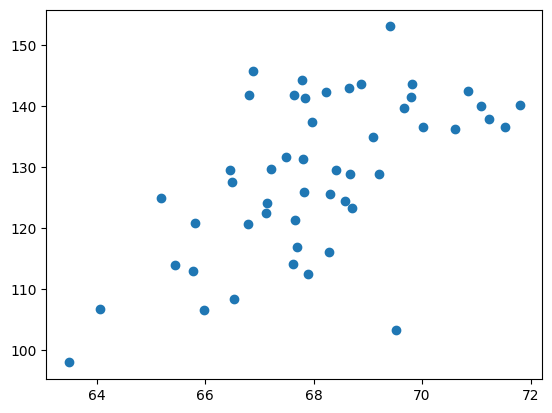

In [282]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.plot(np.array(_weightRdd), np.array(_heightRdd),'o')
plt.show()

In [283]:
#matplotlib는 팝업이 뜰 수 있는데 % inline으로 창이 안 뜨게 할 수 있다
#plot에다가 x랑 y축 지정해준 것

In [285]:
#또 다른 차트
#boxplot, violinplot

In [286]:
#data는 무슨 datatpye일지 생각해야함

In [287]:
#멀티 data가 오면 숫자(기술통계, 추론통계)로 가고 text는 머신러닝으로 보통 간다
#여기선 숫자 데이터니까 아래와같이도 나타낼 수 있음

In [288]:
height = tDf.select("height").toPandas()

In [289]:
height.describe()

,height
count,50.00000
mean,68.05240
std,1.82398
min,63.48000
25%,66.94000
50%,67.86500
75%,69.18000
max,71.80000


In [290]:
type(height)

pandas.core.frame.DataFrame

In [292]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(20, 10))

#121은 무슨 뜻? 1: 행. 2: 컬럼. 
#1은 첫번째꺼에 넣겠다 그럼 그 오른쪽은? 1,2,2가 되겠지?
ax1 = fig.add_subplot(1, 2, 1)  # subplot location
ax1 = plt.boxplot(height)

#이건 오른쪽에다 보내겠다는 거겠지?
ax2 = fig.add_subplot(1, 2, 2)
ax2 = sns.violinplot(data=height)

ModuleNotFoundError: No module named 'seaborn'

In [294]:
#aggregate functions 함수
#분석을 한다는 건 늘 집단화해서 개별값은 없어지지만 집계값은 남는다 집계하는 건 거의 필수라고 할 수 있어
#아래는 집계하는 함수임

In [295]:
#딕셔너리 형식이다
tDf.agg({"height":"count"}).show()

+-------------+
|count(height)|
+-------------+
|           50|
+-------------+



In [298]:
tDf.agg({"height":"kurtosis"}).show()
#분포의 생긴 모양

+--------------------+
|    kurtosis(height)|
+--------------------+
|-0.00944222604387468|
+--------------------+



In [299]:
tDf.agg({"height":"avg"}).show()
#평균 모양

+-----------------+
|      avg(height)|
+-----------------+
|68.05240000000002|
+-----------------+



In [300]:
from pyspark.sql import functions as F
tDf.agg(F.min("height")).show()

+-----------+
|min(height)|
+-----------+
|      63.48|
+-----------+

